**IMPORT LIBARIES**

In [1]:
!pip install distance

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.3/180.3 kB 4.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for distance: filename=Distance-0.1.3-py3-none-any.whl size=16256 sha256=c0de8176a6ff6fa5d6ed7b417439d63b24da08d8ddcfaaba64be71c9fd4ff731
  Stored in directory: /root/.cache/pip/wheels/fb/cd/9c/3ab5d666e3bcacc58900b10959edd3816cc9557c7337986322
Successfully built distance


In [2]:
import os
import pickle as pkl
import multiprocessing as mp
import random
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch import Tensor
from torchvision import transforms
from torch.utils.data import DataLoader, Sampler
from torch.nn.utils.rnn import pad_sequence
from torch.nn import init
from torch.nn.utils import clip_grad_norm_
from torch.distributions.uniform import Uniform
from torchvision.models import resnet18, ResNet18_Weights
from torch.optim.lr_scheduler import ReduceLROnPlateau
from datasets import load_from_disk, Dataset
from os.path import join
from typing import List, Iterator, Literal
from tqdm import tqdm
from collections import defaultdict
import nltk
import distance
import copy
import matplotlib.pyplot as plt

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

**GLOBAL CONFIGURATIONS**

In [3]:
NUM_WORKERS = mp.cpu_count()

In [4]:
class Config:
    data_path = "/kaggle/input/im2latex-100k/dataset"
    vocab_path = "/kaggle/input/im2latex-100k/vocab.pkl"
    save_dir = "./Checkpoint"

    # Model args
    word_emb_dim = 80
    rnn_h_dim = 512
    rnn_o_dim = 512
    enc_out_dim = 512
    att_dim = 512

    # Training args
    dropout = 0.2
    cuda = True
    batch_size = 64
    accumulation_steps = 1
    epoches = 50
    lr = 2e-4
    min_lr = 2e-5
    label_smoothing = 0.1

    # Sampling & Decay
    sample_method = "inv_sigmoid"  # choices: 'teacher_forcing', 'exp', 'inv_sigmoid'
    decay_k = 4000
    lr_decay = 0.5
    lr_patience = 5
    clip = 2.0

    # Learning rate warpup
    warmup_lr = 1e-4
    warmup_epochs = 2
    
    # Early stopping
    es_patience = 10
    es_min_delta = 1e-3

    # Misc
    seed = 2025

    # Checkpoint settings
    from_check_point = False

    # Evaluation
    result_path = "./Result.txt"
    ref_path = "./Ref.txt"
    eval_batch_size = 64
    beam_size = 5
    max_len = 150

In [5]:
def seed_everything(seed):
    # 1. Python & Numpy
    random.seed(seed)
    np.random.seed(seed)

    # 2. PyTorch
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        if torch.cuda.device_count() > 1:
            torch.cuda.manual_seed_all(seed)

    # 3. CuDNN
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [6]:
args = Config()
if args.seed is not None:
    seed_everything(args.seed)

use_cuda = True if args.cuda and torch.cuda.is_available() else False
device = torch.device("cuda" if use_cuda else "cpu")
print(f"Using device: {device}")

Using device: cuda


# 1. DATA PREPARATION

## 1.1. Configurations

In [7]:
START_TOKEN_ID = 0
PAD_TOKEN_ID = 1
END_TOKEN_ID = 2
UNK_TOKEN_ID = 3

## 1.2. Load data

### 1.2.1. Utils

In [8]:
class Vocab:
    def __init__(self):
        self.sign2id = {
            "<s>": START_TOKEN_ID,
            "</s>": END_TOKEN_ID,
            "<pad>": PAD_TOKEN_ID,
            "<unk>": UNK_TOKEN_ID,
        }
        self.id2sign = dict((idx, token) for token, idx in self.sign2id.items())
        self.length = 4

    def add_sign(self, sign):
        if sign not in self.sign2id:
            self.sign2id[sign] = self.length
            self.id2sign[self.length] = sign
            self.length += 1

    def __len__(self) -> int:
        return self.length

In [9]:
def load_vocab(filepath: str) -> Vocab:
    with open(filepath, "rb") as f:
        vocab: Vocab = pkl.load(f)
    print(f"Load vocab including {len(vocab)} Latex tokens.")
    return vocab

### 1.2.2. Load data

In [10]:
vocab = load_vocab(args.vocab_path)
vocab_size = len(vocab)

Load vocab including 394 Latex tokens.


## 1.3. Create DataLoader

### 1.3.1. Configurations

In [11]:
MAX_SIZE = 800

### 1.3.2 Utils

In [12]:
class SmartBucketSampler(Sampler):
    def __init__(
        self,
        data_source: Dataset,
        batch_size: int,
        shuffle: bool = True,
        drop_last: bool = False,
        seed: int = None,
    ):
        self.data_source = data_source
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.drop_last = drop_last
        self.seed = seed
        self.epoch = 0  # To keep track of epochs

        # Create the buckets based on image sizes (w, h)
        self.buckets = defaultdict(list)
        print("Initializing Sampler... (Loading sizes)")

        # Assume data_source is a HuggingFace dataset or dict with 'width', 'height'
        # If it's a list of custom objects, you need to modify the access method
        widths = data_source["width"]
        heights = data_source["height"]

        for idx, (w, h) in enumerate(zip(widths, heights)):
            self.buckets[(w, h)].append(idx)

        print(f"Sampler initialized. Found {len(self.buckets)} unique buckets.")

        self.total_batches = 0
        for indices in self.buckets.values():
            self.total_batches += len(indices) // self.batch_size
            if not self.drop_last and len(indices) % self.batch_size != 0:
                self.total_batches += 1

    def __iter__(self) -> Iterator[List[int]]:
        batches = []

        if self.seed is not None:
            generator_seed = self.seed + self.epoch
            rng = random.Random(generator_seed)
        else:
            rng = random

        bucket_keys = list(self.buckets.keys())

        if self.shuffle:
            rng.shuffle(bucket_keys)

        for key in bucket_keys:
            # Copy list indices to avoid modifying the original data
            indices = self.buckets[key][:]

            if self.shuffle:
                rng.shuffle(indices)

            # Split into chunks
            for i in range(0, len(indices), self.batch_size):
                batch = indices[i : i + self.batch_size]

                if len(batch) == self.batch_size:
                    batches.append(batch)
                elif not self.drop_last:
                    batches.append(batch)

        if self.shuffle:
            rng.shuffle(batches)

        for batch in batches:
            yield batch

    def __len__(self) -> int:
        return self.total_batches

    def set_epoch(self, epoch: int) -> None:
        self.epoch = epoch

In [13]:
# Transform images
def smart_resize(img, max_side=800):
    """
    Resize ảnh nếu cạnh lớn nhất vượt quá max_side.
    Giữ nguyên tỷ lệ (Aspect Ratio).
    """
    w, h = img.size
    if w <= max_side and h <= max_side:
        return img # Ảnh nhỏ thì giữ nguyên
        
    # Tính toán kích thước mới
    ratio = max_side / max(w, h)
    new_w = int(w * ratio)
    new_h = int(h * ratio)
    
    # Resize với bộ lọc LANCZOS để giữ nét
    return img.resize((new_w, new_h), Image.Resampling.LANCZOS)


img_transform = transforms.Compose(
    [
        transforms.Grayscale(num_output_channels=1),
        transforms.ToTensor(),
    ]
)


def latex_collate_fn(batch) -> tuple[Tensor, Tensor]:
    imgs = []
    formulas = []

    for item in batch:
        pil_image = item["image"]
        pil_image = smart_resize(pil_image, max_side=MAX_SIZE)
        imgs.append(img_transform(pil_image))
        
        raw_formula = item["formula"]
        tokens = raw_formula.split()

        formula_indices = [
            vocab.sign2id.get(token, vocab.sign2id["<unk>"]) for token in tokens
        ]
        formula_indices = (
            [vocab.sign2id["<s>"]] + formula_indices + [vocab.sign2id["</s>"]]
        )
        formula_tensor = torch.tensor(formula_indices, dtype=torch.long)

        formulas.append(formula_tensor)

    imgs = torch.stack(imgs)
    formulas = pad_sequence(
        formulas, batch_first=True, padding_value=vocab.sign2id["<pad>"]
    )

    return imgs, formulas

### 1.3.2. Setup sampler

In [14]:
processed_dataset = load_from_disk(args.data_path)

In [15]:
train_sampler = SmartBucketSampler(
    processed_dataset["train"],
    batch_size=args.batch_size,
    shuffle=True,
    drop_last=True,
    seed=args.seed,
)

val_sampler = SmartBucketSampler(
    processed_dataset["validation"],
    batch_size=args.batch_size,
    shuffle=False,
    drop_last=False,
    seed=args.seed,
)

test_sampler = SmartBucketSampler(
    processed_dataset["test"],
    batch_size=args.eval_batch_size,
    shuffle=False,
    drop_last=False,
    seed=args.seed,
)

Initializing Sampler... (Loading sizes)
Sampler initialized. Found 19 unique buckets.
Initializing Sampler... (Loading sizes)
Sampler initialized. Found 19 unique buckets.
Initializing Sampler... (Loading sizes)
Sampler initialized. Found 22 unique buckets.


### 1.3.3. DataLoader

In [16]:
def seed_worker(worker_id: int):
    worker_seed = (torch.initial_seed() + worker_id) % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

In [17]:
worker_init = seed_worker if (args.seed is not None) else None

train_loader = DataLoader(
    processed_dataset["train"],
    batch_sampler=train_sampler,
    collate_fn=latex_collate_fn,
    num_workers=NUM_WORKERS,
    pin_memory = True if use_cuda else False,
    worker_init_fn=worker_init,
)

val_loader = DataLoader(
    processed_dataset["validation"],
    batch_sampler=val_sampler,
    collate_fn=latex_collate_fn,
    num_workers=NUM_WORKERS,
    pin_memory = True if use_cuda else False,
    worker_init_fn=worker_init,
)

test_loader = DataLoader(
    processed_dataset["test"],
    batch_sampler=test_sampler,
    collate_fn=latex_collate_fn,
    num_workers=NUM_WORKERS,
    pin_memory = True if use_cuda else False,
    worker_init_fn=worker_init,
)

In [18]:
print(f"Total batches: {len(train_loader)}")
for batch_idx, (images, formulas) in enumerate(train_loader):
    print(f"Batch {batch_idx}:")

    print(f" - Image shape: {images.shape}")
    print(f" - Formula shape: {formulas.shape}")

    if batch_idx == 2:
        break

Total batches: 1167
Batch 0:
 - Image shape: torch.Size([64, 1, 64, 384])
 - Formula shape: torch.Size([64, 145])
Batch 1:
 - Image shape: torch.Size([64, 1, 64, 384])
 - Formula shape: torch.Size([64, 148])
Batch 2:
 - Image shape: torch.Size([64, 1, 64, 384])
 - Formula shape: torch.Size([64, 151])


# 2. IM2LATEX MODEL

## 2.1. Configurations

In [19]:
INIT_VALUE = 1e-2

## 2.2. Positional Encoding

In [20]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 5000, dropout: float = 0.1):
        """
        Args:
            d_model: latent vector size (embedding size)
            max_len: max sequence length
            dropout: dropout rate
        """
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        # Create a PE matrix with size (max_len, d_model)
        pe = torch.zeros(max_len, d_model)

        # Position: [max_len, 1]
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)

        # Calculate div_term (denominator) in log space for better precision
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )

        # Apply sin for even-indexed positions (2i)
        pe[:, 0::2] = torch.sin(position * div_term)

        # Apply cos for odd-indexed positions (2i+1)
        pe[:, 1::2] = torch.cos(position * div_term)

        # Add batch dim (1, max_len, d_model) for broadcasting when adding to embedding
        pe = pe.unsqueeze(0)

        # Register buffer so that it's not treated as learnable parameter,
        # However it will still be included in the model's state_dict
        self.register_buffer("pe", pe)

    def forward(self, x: Tensor) -> Tensor:
        """
        Args:
            x: Input tensor with dim (Batch_size, Seq_len, d_model)
        """
        # Adding PE to embedding input (cut according to the actual length of x)
        x = x + self.pe[:, : x.size(1), :]
        return self.dropout(x)

## 2.3 Encoder

In [21]:
class Encoder(nn.Module):
    def __init__(
        self,
        enc_out_dim: int,
        dropout: float,
    ) -> None:
        super().__init__()

        # -------- ResNet backbone --------
        weights = ResNet18_Weights.IMAGENET1K_V1
        resnet = resnet18(weights=weights)

        # ---- Modify for grayscale input ----
        self.conv1 = nn.Conv2d(
            1, 64,
            kernel_size=7,
            stride=(2, 1),      # keep width
            padding=3,
            bias=False
        )

        # copy pretrained weights (RGB → Gray)
        # Sử dụng thuộc tính của resnet, không cần lưu trữ resnet sau này
        self.conv1.weight.data = (
            resnet.conv1.weight.data.mean(dim=1, keepdim=True)
        )

        # Gán các module con của ResNet vào lớp Encoder
        self.bn1 = resnet.bn1
        self.relu = resnet.relu
        self.maxpool = nn.MaxPool2d(
            kernel_size=3,
            stride=(2, 1),
            padding=1
        )

        # [MỚI] GOM NHÓM TIỀN XỬ LÝ ĐẦU VÀO
        self.initial_block = nn.Sequential(
            self.conv1,
            self.bn1,
            self.relu,
            self.maxpool,
        )

        # [MỚI] GOM NHÓM CÁC STAGE CHÍNH CỦA RESNET
        self.resnet_layers = nn.Sequential(
            resnet.layer1,      # 64
            resnet.layer2,      # 128
            resnet.layer3,      # 256
            resnet.layer4,      # 512
        )

        # -------- Projection to enc_out_dim --------
        self.proj = nn.Sequential(
            nn.Conv2d(512, enc_out_dim, kernel_size=1),
            nn.BatchNorm2d(enc_out_dim),
            nn.ReLU(True)
        )

        # Largest image ~800x800 -> after downsample ≈ <100x100
        self.pos_encoder = PositionalEncoding(
            enc_out_dim, 10000, dropout
        )


    def forward(self, imgs: Tensor) -> Tensor:
            """
            imgs: [B, 1, H, W]
            """
    
            # 1. Khối tiền xử lý ban đầu (conv, bn, relu, maxpool)
            x = self.initial_block(imgs)
    
            # 2. Các tầng chính của ResNet (Layer 1-4)
            x = self.resnet_layers(x)
            # x shape: [B, 512, H', W']
    
            # 3. Projection
            x = self.proj(x)  # [B, C, H', W']
            B, C, H, W = x.shape
    
            # 4. Flatten spatial → sequence
            x = x.permute(0, 2, 3, 1)  # [B, H', W', C]
            x = x.contiguous().view(B, H * W, C) # [B, L, C]
    
            # 5. Positional encoding
            x = x * math.sqrt(C)
            x = self.pos_encoder(x)
    
            return x  # [B, L, enc_out_dim]

## 2.4 Decoder

In [22]:
class Decoder(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        word_emb_dim: int,
        rnn_h_dim: int,
        rnn_o_dim: int,
        enc_out_dim: int,
        att_dim: int,
        dropout: float
    ) -> None:
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, word_emb_dim)
        self.rnn_decoder = nn.LSTMCell(rnn_o_dim + word_emb_dim, rnn_h_dim)
        self.dropout = nn.Dropout(dropout)

        # Init layers
        self.init_wh = nn.Linear(enc_out_dim, rnn_h_dim)
        self.init_wc = nn.Linear(enc_out_dim, rnn_h_dim)
        self.init_wo = nn.Linear(enc_out_dim, rnn_o_dim)

        # Attention layers
        self.beta = nn.Parameter(
            torch.Tensor(att_dim)
        )

        # Has a reasonable initial value (not too large, not too small). Helps the network learn attention scores stably from the start.
        init.uniform_(self.beta, -INIT_VALUE, INIT_VALUE)

        self.W_1 = nn.Linear(enc_out_dim, att_dim, bias=False)
        self.W_2 = nn.Linear(rnn_h_dim, att_dim, bias=False)
        self.W_3 = nn.Linear(rnn_h_dim + enc_out_dim, rnn_o_dim, bias=False)
        self.W_out = nn.Linear(rnn_o_dim, vocab_size, bias=False)

    def init_decoder_states(self, enc_out: Tensor) -> tuple[tuple[Tensor, Tensor], Tensor]:
        """
        Args:
          enc_out: the output of encoder [B, H*W, C]
        Returns:
          h_0, c_0:  h_0 and c_0's shape: [B, rnn_h_dim]
          init_o : the average of enc_out  [B, rnn_o_dim]
          for decoder
        """
        mean_enc_out = enc_out.mean(dim=1)  # [B, H*W, C] -> [B, C]
        h = torch.tanh(self.init_wh(mean_enc_out))   
        c = torch.tanh(self.init_wc(mean_enc_out))
        init_o = torch.tanh(self.init_wo(mean_enc_out))
        return (h, c), init_o

    def forward_step(
        self,
        dec_states: tuple[Tensor, Tensor],
        o_t: Tensor,
        enc_out: Tensor,
        projected_enc: Tensor,
        tgt: Tensor,
    ) -> tuple[tuple[Tensor, Tensor], Tensor, Tensor]:
        """Runing one step decoding"""

        # RNN stage
        prev_y = self.embedding(tgt).squeeze(1)  # prev_y's shape: [B, emb_size]
        inp = torch.cat([prev_y, o_t], dim=1)  # inp's shape: [B, emb_size + rnn_o_dim]
        h_t, c_t = self.rnn_decoder(inp, dec_states)  # h_t and c_t's shape: [B, rnn_h_dim]
        h_t = self.dropout(h_t)
        c_t = self.dropout(c_t)

        # Attention stage
        alpha = torch.tanh(
            projected_enc + self.W_2(h_t).unsqueeze(1)
        )  # [B, L, att_dim] + [B, 1, att_dim] -> [B, L, att_dim]
        alpha = torch.sum(self.beta * alpha, dim=-1)  # [B, L]
        alpha = F.softmax(alpha, dim=-1)  # [B, L]

        # calc context: [B, C]
        context_t = torch.bmm(
            alpha.unsqueeze(1), enc_out
        )  # batch mat mult [B, 1, L] @ [B, L, C] -> [B, 1, C]
        context_t = context_t.squeeze(1) # [B, 1, C] -> [B, C]

        # Output stage
        o_t = self.W_3(torch.cat([h_t, context_t], dim=1)).tanh()
        o_t = self.dropout(o_t)
        logit = self.W_out(o_t)  # [B, vocab_size]

        return (h_t, c_t), o_t, logit

## 2.3. Model

In [23]:
class Im2LatexModel(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        word_emb_dim: int,
        rnn_h_dim: int,
        rnn_o_dim: int,
        enc_out_dim: int,
        att_dim: int,
        dropout: float,
    ) -> None:
        super().__init__()

        self.encoder = Encoder(enc_out_dim, dropout)
        self.decoder = Decoder(vocab_size, word_emb_dim, rnn_h_dim, rnn_o_dim, enc_out_dim, att_dim, dropout)
        self.uniform = Uniform(0, 1) # Schedule sampling

    
    def forward(self, imgs: Tensor, formulas: Tensor, epsilon: float) -> Tensor:
        """
        Args:
            imgs: [B, 1, H, W]
            formulas: [B, MAX_LEN], each token is a number
            epsilon: probability of the current time step to
                    use the true previous token
        Returns:
            logits: [B, MAX_LEN, VOCAB_SIZE]
        """
        # 1. Encoding
        enc_out = self.encoder(imgs)  # [B, 1, H, W] -> [B, H'*W', 512]

        # 2. Initialize decoder states
        dec_states, o_t = self.decoder.init_decoder_states(enc_out)

        # 3. Precompute for better performance, its shape: [B, L, att_dim]
        projected_encoder_output = self.decoder.W_1(enc_out)

        # 4. Loop to decode
        max_len = formulas.size(1)
        logits = []
        prev_logit = None
        for t in range(max_len):
            tgt = formulas[:, t : t + 1]  # True label, shape: [B, 1]

            # Schedule sampling
            if prev_logit is not None and self.uniform.sample().item() > epsilon:
                tgt = torch.argmax(prev_logit.detach(), dim=1, keepdim=True) 

            # One step decoding
            dec_states, o_t, logit = self.decoder.forward_step(
                    dec_states, o_t, enc_out, projected_encoder_output, tgt
            )  # At each step returns 1 batch, logit: [B, vocab_size]
            
            prev_logit = logit.detach()
            logits.append(logit)

        logits = torch.stack(logits, dim=1)  # [B, MAX_LEN, vocab_size]
        return logits

# 3. TRAINING

## 3.1. Helper function

**Functions for trainer**

In [24]:
def cal_loss(logits: Tensor, targets: Tensor, label_smoothing: float = 0.1) -> Tensor:
    "logits: [B, L, V], targets: [B, L]"

    # [B*L, V] each row [V] in logits_flat corresponds to a token in the batch
    logits_flat = logits.contiguous().view(-1, logits.size(-1))

    # [B*L] Each value in targets_flat is the correct token index
    targets_flat = targets.contiguous().view(-1)

    # Calculate cross entropy loss
    return F.cross_entropy(logits_flat, targets_flat, ignore_index=PAD_TOKEN_ID, label_smoothing=label_smoothing)


def cal_epsilon(
    k: float, step: int, method: Literal["inv_sigmoid", "exp", "teacher_forcing"]
) -> float:
    """
    Reference:
        Scheduled Sampling for Sequence Prediction with Recurrent Neural Networks
        See details in https://arxiv.org/pdf/1506.03099.pdf
    """
    assert method in ["inv_sigmoid", "exp", "teacher_forcing"]

    if method == "exp":
        return k**step
    elif method == "inv_sigmoid":
        return k / (k + math.exp(step / k))
    else:
        return 1.0

**Function to get our checkpoint**

In [25]:
def get_checkpoint(save_dir, mode="latest") -> str:
    """
    Auto find checkpoint (New format only).
    - mode='latest': returns path to 'last_model.pt'
    - mode='best': returns path to 'best_model.pt'
    """
    if not os.path.exists(save_dir):
        raise FileNotFoundError(f"Directory does not exist: {save_dir}")

    # Xác định tên file dựa trên mode
    if mode == "latest":
        target_name = "last_model.pt"
    elif mode == "best":
        target_name = "best_model.pt"
    else:
        raise ValueError(f"Unknown mode: {mode}. Use 'latest' or 'best'.")

    target_path = join(save_dir, target_name)

    # Kiểm tra file có tồn tại không
    if not os.path.exists(target_path):
        raise FileNotFoundError(f"Checkpoint '{target_name}' not found in {save_dir}")

    print(f"Found {mode} checkpoint: {target_path}")
    return target_path

**Learning rate scheduler wrapper**

In [26]:
class ConstantWarmupScheduler:
    def __init__(
        self, 
        optimizer, 
        warmup_epochs, 
        warmup_lr, 
        target_lr, 
        plateau_scheduler
    ):
        self.optimizer = optimizer
        self.warmup_epochs = warmup_epochs
        self.warmup_lr = warmup_lr
        self.target_lr = target_lr
        self.plateau_scheduler = plateau_scheduler
        self.last_epoch = 0

        # [QUAN TRỌNG] Set ngay LR khởi điểm là warmup_lr
        for param_group in self.optimizer.param_groups:
            param_group['lr'] = self.warmup_lr

    def step(self, metrics):
        self.last_epoch += 1

        # Giai đoạn 1: Đang trong thời gian Warmup
        if self.last_epoch < self.warmup_epochs:
            # Giữ nguyên LR thấp
            for param_group in self.optimizer.param_groups:
                param_group['lr'] = self.warmup_lr
        
        # Giai đoạn 2: Vừa hết Warmup -> Nhảy lên Target LR
        elif self.last_epoch == self.warmup_epochs:
            print(f"\n[Scheduler] Warmup finished! Jumping LR to {self.target_lr}")
            for param_group in self.optimizer.param_groups:
                param_group['lr'] = self.target_lr
            
            # Reset internal state của Plateau để nó bắt đầu theo dõi từ mốc này
            # (tránh việc nó tính loss của giai đoạn warmup vào bad_counts)
            self.plateau_scheduler._reset() 

        # Giai đoạn 3: Sau Warmup -> Giao cho ReduceLROnPlateau
        else:
            self.plateau_scheduler.step(metrics)

    def state_dict(self):
        return {
            'last_epoch': self.last_epoch,
            'plateau_state': self.plateau_scheduler.state_dict()
        }

    def load_state_dict(self, state_dict):
        self.last_epoch = state_dict['last_epoch']
        self.plateau_scheduler.load_state_dict(state_dict['plateau_state'])

## 3.2. Trainer

In [27]:
class Trainer(object):
    def __init__(
        self,
        optimizer,
        model,
        train_loader,
        val_loader,
        args,
        lr_scheduler,
        use_cuda=True,
        init_epoch=1,
        last_epoch=200,
    ):

        self.device = torch.device("cuda" if use_cuda else "cpu")
        self.model = model.to(self.device)
        if torch.cuda.device_count() > 1:
            print(f"Detect {torch.cuda.device_count()} GPUs! Running in parallel.")
            self.model = nn.DataParallel(self.model)
        
        self.optimizer = optimizer
        self.train_loader = train_loader
        self.val_loader = val_loader

        self.epoch = init_epoch
        self.total_step = (init_epoch - 1) * len(train_loader)
        self.last_epoch = last_epoch
        self.best_val_loss = 1e18

        self.args = args
        self.lr_scheduler = lr_scheduler
        self.wait = 0

    def train(self):
        # [NEW] Khởi tạo history để lưu loss
        history = {'train_loss': [], 'val_loss': []}

        while self.epoch <= self.last_epoch:
            self.model.train()
            self.train_loader.batch_sampler.set_epoch(self.epoch)

            pbar = tqdm(
                self.train_loader,
                desc=f"Epoch {self.epoch}/{self.last_epoch}",
                unit="batch",
                leave=False,
            )
            epoch_losses = 0.0

            self.optimizer.zero_grad(set_to_none=True)

            for i, (imgs, formulas) in enumerate(pbar):
                imgs: Tensor = imgs.to(self.device)
                formulas: Tensor = formulas.to(self.device)

                tgt4training = formulas[:, :-1]
                tgt4cal_loss = formulas[:, 1:]

                step_loss = self.train_step(imgs, tgt4training, tgt4cal_loss, i)

                epoch_losses += step_loss
                current_avg_loss = epoch_losses / (i + 1)
                current_lr = self.optimizer.param_groups[0]["lr"]

                pbar.set_postfix(
                    {
                        "Loss": f"{step_loss:.4f}",
                        "Avg Loss": f"{current_avg_loss:.4f}",
                        "Ppl": f"{math.exp(current_avg_loss):.4f}",
                        "LR": f"{current_lr:.6f}",
                    }
                )
            avg_train_loss = epoch_losses / len(self.train_loader)
            history['train_loss'].append(avg_train_loss)

            # Validate
            val_loss = self.validate()
            # [NEW] Lưu Val Loss
            history['val_loss'].append(val_loss)

            self.lr_scheduler.step(val_loss)

            self.save_model("last_model") 


            if val_loss < (self.best_val_loss - self.args.es_min_delta):
                print(
                    f"Validation loss improved from {self.best_val_loss:.4f} -> {val_loss:.4f}. Saving best model..."
                )
                self.best_val_loss = val_loss
                self.save_model("best_model")
                self.wait = 0
            else:
                self.wait += 1
                print(
                    f"EarlyStopping counter: {self.wait} out of {self.args.es_patience}"
                )
                if self.wait >= self.args.es_patience:
                    print("Early stopping triggered! Stop training.")
                    break

            self.epoch += 1
        
        # [NEW] Trả về history để vẽ biểu đồ
        return history

    def train_step(
        self, imgs: Tensor, tgt4training: Tensor, tgt4cal_loss: Tensor, step_idx: int
    ) -> float:
        # Code gốc đã bỏ Autocast/Scaler theo yêu cầu trước đó
        epsilon = cal_epsilon(
            self.args.decay_k, self.total_step, self.args.sample_method
        )

        logits = self.model(imgs, tgt4training, epsilon)
        loss = cal_loss(logits.float(), tgt4cal_loss, self.args.label_smoothing)
        loss = loss / self.args.accumulation_steps

        loss.backward() 

        if (step_idx + 1) % self.args.accumulation_steps == 0:
            clip_grad_norm_(self.model.parameters(), self.args.clip)
            self.optimizer.step()
            self.optimizer.zero_grad(set_to_none=True)
            self.total_step += 1

        return loss.item() * self.args.accumulation_steps

    def validate(self) -> float:
        self.model.eval()
        val_total_loss = 0.0

        pbar = tqdm(self.val_loader, desc=f"Validating Epoch {self.epoch}", unit="batch", leave=False)

        with torch.no_grad():
            for i, (imgs, formulas) in enumerate(pbar):
                imgs = imgs.to(self.device)
                formulas = formulas.to(self.device)

                tgt4training = formulas[:, :-1]
                tgt4cal_loss = formulas[:, 1:]
                
                epsilon = 1

                logits = self.model(imgs, tgt4training, epsilon)
                loss = cal_loss(logits, tgt4cal_loss, label_smoothing=0.0)

                val_total_loss += loss.item()
                current_avg_loss = val_total_loss / (i + 1)
                pbar.set_postfix(
                    {
                        "Val Loss": f"{loss.item():.4f}",
                        "Avg Loss": f"{current_avg_loss:.4f}",
                        "Ppl": f"{math.exp(current_avg_loss):.4f}",
                    }
                )

            avg_loss = val_total_loss / len(self.val_loader)

            print(
                f"\nValidation Result - Epoch {self.epoch}: "
                f"Avg Loss: {avg_loss:.4f}, "
                f"Perplexity: {math.exp(avg_loss):.4f}\n"
            )

        return avg_loss


    def find_lr(self, init_value=1e-7, final_value=10.0, beta=0.98):
        """
        Thuật toán LR Finder: Tăng LR theo cấp số nhân sau mỗi batch
        để tìm điểm gãy (loss bùng nổ) và điểm dốc nhất (học nhanh nhất).
        """
        print("Running LR Finder...")
        
        # Lưu lại state ban đầu để restore sau khi chạy xong
        # Vì chạy cái này sẽ làm model weights bị nhảy lung tung
        initial_model_state = copy.deepcopy(self.model.state_dict())
        initial_optimizer_state = copy.deepcopy(self.optimizer.state_dict())
        
        self.model.train()
        num = len(self.train_loader) - 1
        mult = (final_value / init_value) ** (1 / num)
        
        lr = init_value
        self.optimizer.param_groups[0]['lr'] = lr
        
        avg_loss = 0.0
        best_loss = 0.0
        batch_num = 0
        losses = []
        log_lrs = []
        
        pbar = tqdm(self.train_loader, desc="Finding LR", leave=True)
        
        for i, (imgs, formulas) in enumerate(pbar):
            batch_num += 1
            imgs = imgs.to(self.device)
            formulas = formulas.to(self.device)

            # Chuẩn bị dữ liệu (giống hàm train_step)
            tgt4training = formulas[:, :-1]
            tgt4cal_loss = formulas[:, 1:]
            epsilon = 1 # Force teacher forcing khi test LR cho ổn định

            # Forward & Loss
            self.optimizer.zero_grad()
            logits = self.model(imgs, tgt4training, epsilon)
            loss = cal_loss(logits.float(), tgt4cal_loss, self.args.label_smoothing)
            
            # Tính smoothed loss để biểu đồ mượt hơn
            current_loss = loss.item()
            avg_loss = beta * avg_loss + (1 - beta) * current_loss
            smoothed_loss = avg_loss / (1 - beta**batch_num)
            
            # Dừng nếu loss bùng nổ (gấp 4 lần loss tốt nhất) hoặc gặp NaN
            if batch_num > 1 and (smoothed_loss > 4 * best_loss or math.isnan(smoothed_loss)):
                print(f"Loss exploded at LR={lr:.6f}. Stopping...")
                break
                
            if smoothed_loss < best_loss or batch_num == 1:
                best_loss = smoothed_loss
                
            losses.append(smoothed_loss)
            log_lrs.append(math.log10(lr))
            
            # Backward & Step
            loss.backward()
            self.optimizer.step()
            
            # Update LR cho batch tiếp theo
            lr *= mult
            self.optimizer.param_groups[0]['lr'] = lr
            
            pbar.set_postfix({'LR': f"{lr:.6f}", 'Loss': f"{smoothed_loss:.4f}"})
        
        # Restore lại model sạch ban đầu
        print("Restoring original model & optimizer state...")
        self.model.load_state_dict(initial_model_state)
        self.optimizer.load_state_dict(initial_optimizer_state)
        
        return log_lrs, losses

    def save_model(self, model_name: str):
        if not os.path.isdir(self.args.save_dir):
            os.makedirs(self.args.save_dir)
        
        # model_name bây giờ sẽ là "best_model" hoặc "last_model"
        save_path = join(self.args.save_dir, model_name + ".pt")

        if isinstance(self.model, nn.DataParallel):
            model_state_dict = self.model.module.state_dict()
        else:
            model_state_dict = self.model.state_dict()

        torch.save(
            {
                "epoch": self.epoch,
                "model_state_dict": model_state_dict,
                "optimizer_state_dict": self.optimizer.state_dict(),
                "lr_sche": self.lr_scheduler.state_dict(),
                "args": self.args,
                "best_val_loss": self.best_val_loss,
                "wait": self.wait,
            },
            save_path,
        )

## 3.3. Perform training

**Load model**

In [28]:
model = Im2LatexModel(
    vocab_size,
    args.word_emb_dim,
    args.rnn_h_dim,
    args.rnn_o_dim,
    args.enc_out_dim,
    args.att_dim,
    args.dropout,
)
print(model)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 190MB/s]


Im2LatexModel(
  (encoder): Encoder(
    (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 1), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=(2, 1), padding=1, dilation=1, ceil_mode=False)
    (initial_block): Sequential(
      (0): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 1), padding=(3, 3), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=3, stride=(2, 1), padding=1, dilation=1, ceil_mode=False)
    )
    (resnet_layers): Sequential(
      (0): Sequential(
        (0): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU(inplace=True)
     

**Setup optimizer and others**

In [29]:
# Construct optimizer
optimizer = optim.Adam(model.parameters(), lr=args.lr)

base_scheduler = ReduceLROnPlateau(
    optimizer,
    "min",
    factor=args.lr_decay,
    patience=args.lr_patience,
    min_lr=args.min_lr,
)

lr_scheduler = ConstantWarmupScheduler(
    optimizer=optimizer,
    warmup_epochs=args.warmup_epochs, 
    warmup_lr=args.warmup_lr,         
    target_lr=args.lr,                
    plateau_scheduler=base_scheduler
)

print("Model and Optimizer initialized.")

Model and Optimizer initialized.


**Let's train**

In [30]:
# --- 1. Init temp var ---
start_epoch = 1
loaded_best_loss = 1e18
loaded_wait = 0

if args.from_check_point:
    print("Loading checkpoint...")
    checkpoint_path = get_checkpoint(args.save_dir)
    checkpoint = torch.load(checkpoint_path, weights_only=False)

    args = checkpoint["args"]
    args.from_check_point = False

    if isinstance(model, nn.DataParallel):
        model.module.load_state_dict(checkpoint["model_state_dict"])
    else:
        model.load_state_dict(checkpoint["model_state_dict"])

    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    lr_scheduler.load_state_dict(checkpoint["lr_sche"])

    # Load state var
    start_epoch = checkpoint["epoch"] + 1
    loaded_best_loss = checkpoint["best_val_loss"]
    loaded_wait = checkpoint["wait"]
    print(f"Resuming from epoch {start_epoch}, Best Loss: {loaded_best_loss:.4f}")

# --- 2. Init Trainer ---
# Now create the trainer object
trainer = Trainer(
    optimizer,
    model,
    train_loader,
    val_loader,
    args,
    lr_scheduler,
    use_cuda=use_cuda,
    init_epoch=start_epoch,
    last_epoch=args.epoches,
)

# --- 3. Inject state to Trainer ---
if args.from_check_point:
    trainer.best_val_loss = loaded_best_loss
    trainer.wait = loaded_wait

# --- 4. Train ---
print("Start Training...")
history = trainer.train()

Detect 2 GPUs! Running in parallel.
Start Training...



Validation Result - Epoch 1: Avg Loss: 1.4300, Perplexity: 4.1788

Validation loss improved from 1000000000000000000.0000 -> 1.4300. Saving best model...



Validation Result - Epoch 2: Avg Loss: 0.6816, Perplexity: 1.9770


[Scheduler] Warmup finished! Jumping LR to 0.0002
Validation loss improved from 1.4300 -> 0.6816. Saving best model...



Validation Result - Epoch 3: Avg Loss: 0.5170, Perplexity: 1.6769

Validation loss improved from 0.6816 -> 0.5170. Saving best model...



Validation Result - Epoch 4: Avg Loss: 0.4047, Perplexity: 1.4988

Validation loss improved from 0.5170 -> 0.4047. Saving best model...


...


Validation Result - Epoch 26: Avg Loss: 0.2374, Perplexity: 1.2680

EarlyStopping counter: 6 out of 10



Validation Result - Epoch 27: Avg Loss: 0.2417, Perplexity: 1.2734

EarlyStopping counter: 7 out of 10



Validation Result - Epoch 28: Avg Loss: 0.2459, Perplexity: 1.2787

EarlyStopping counter: 8 out of 10



Validation Result - Epoch 29: Avg Loss: 0.2555, Perplexity: 1.2912

EarlyStopping counter: 9 out of 10



Validation Result - Epoch 30: Avg Loss: 0.2569, Perplexity: 1.2929

EarlyStopping counter: 10 out of 10
Early stopping triggered! Stop training.


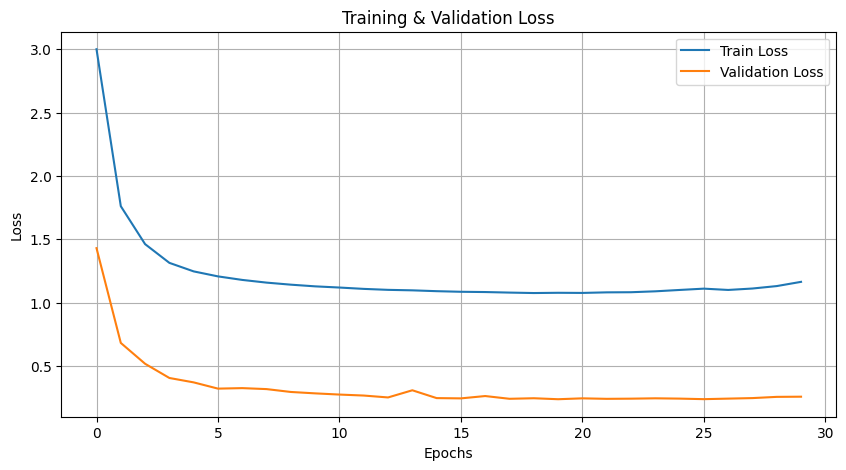

In [31]:
plt.figure(figsize=(10, 5))
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Training & Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.savefig('./training_validation_loss_plot.png') 
plt.show()

# 5. EVALUATION

## 5.1 Utils

### 5.1.1 Utils for decoding

In [32]:
class BeamSearch:
    """
    Implements the beam search algorithm for decoding the most likely sequences.

    Parameters
    ----------
    end_index : ``int``
        The index of the "stop" or "end" token in the target vocabulary.
    max_steps : ``int``, optional (default = 50)
        The maximum number of decoding steps to take, i.e. the maximum length
        of the predicted sequences.
    beam_size : ``int``, optional (default = 10)
        The width of the beam used.
    per_node_beam_size : ``int``, optional (default = beam_size)
        The maximum number of candidates to consider per node, at each step in the search.
        If not given, this just defaults to ``beam_size``. Setting this parameter
        to a number smaller than ``beam_size`` may give better results, 
        as it can introduce more diversity into the search. 
        See `Beam Search Strategies for Neural Machine Translation.
        Freitag and Al-Onaizan, 2017 <http://arxiv.org/abs/1702.01806>`_.
    """

    def __init__(self,
                 end_index: int,
                 max_steps: int = 50,
                 beam_size: int = 10,
                 per_node_beam_size: int = None) -> None:
        self._end_index = end_index
        self.max_steps = max_steps
        self.beam_size = beam_size
        self.per_node_beam_size = per_node_beam_size or beam_size

    def search(self, start_predictions, start_state, step):
        """
        Given a starting state and a step function, apply beam search to find the
        most likely target sequences.

        Notes
        -----
        If your step function returns ``-inf`` for some log probabilities
        (like if you're using a masked log-softmax) then some of the "best"
        sequences returned may also have ``-inf`` log probability. Specifically
        this happens when the beam size is smaller than the number of actions
        with finite log probability (non-zero probability) returned by the step function.
        Therefore if you're using a mask you may want to check the results from ``search``
        and potentially discard sequences with non-finite log probability.

        Parameters
        ----------
        start_predictions : ``torch.Tensor``
            A tensor containing the initial predictions with shape ``(batch_size,)``.
            Usually the initial predictions are just the index of the "start" token
            in the target vocabulary.
        start_state : ``dict``
            The initial state passed to the ``step`` function. 
            Each value of the state dict should be a tensor of shape ``(batch_size, *)``, 
            where ``*`` means any other number of dimensions.
        step : ``function``
            A function that is responsible for computing the next most likely tokens,
            given the current state and the predictions from the last time step.
            The function should accept two arguments. The first being a tensor
            of shape ``(group_size,)``, representing the index of the predicted
            tokens from the last time step, and the second being the current state.
            The ``group_size`` will be ``batch_size * beam_size``, except in the initial
            step, for which it will just be ``batch_size``.
            The function is expected to return a tuple, where the first element
            is a tensor of shape ``(group_size, target_vocab_size)`` containing
            the log probabilities of the tokens for the next step, and the second
            element is the updated state. The tensor in the state should have shape
            ``(group_size, *)``, where ``*`` means any other number of dimensions.

        Returns
        -------
        Tuple[torch.Tensor, torch.Tensor]
            Tuple of ``(predictions, log_probabilities)``, where ``predictions``
            has shape ``(batch_size, beam_size, max_steps)`` and ``log_probabilities``
            has shape ``(batch_size, beam_size)``.
        """
        batch_size = start_predictions.size()[0]

        # List of (batch_size, beam_size) tensors. One for each time step. Does not
        # include the start symbols, which are implicit.
        predictions = []

        # List of (batch_size, beam_size) tensors. One for each time step. None for
        # the first.  Stores the index n for the parent prediction, i.e.
        # predictions[t-1][i][n], that it came from.
        backpointers = []

        # Calculate the first timestep. This is done outside the main loop
        # because we are going from a single decoder input (the output from the
        # encoder) to the top `beam_size` decoder outputs. On the other hand,
        # within the main loop we are going from the `beam_size` elements of the
        # beam to `beam_size`^2 candidates from which we will select the top
        # `beam_size` elements for the next iteration.
        # shape: (batch_size, num_classes)
        start_class_log_probabilities, state = step(
            start_predictions, start_state)

        num_classes = start_class_log_probabilities.size()[1]

        # shape: (batch_size, beam_size), (batch_size, beam_size)
        start_top_log_probabilities, start_predicted_classes = \
            start_class_log_probabilities.topk(self.beam_size)
        if self.beam_size == 1 and (start_predicted_classes == self._end_index).all():
            print("Empty sequences predicted. You may want to "
                  "increase the beam size or ensure "
                  "your step function is working properly.")
            return start_predicted_classes.unsqueeze(-1), start_top_log_probabilities

        # The log probabilities for the last time step.
        # shape: (batch_size, beam_size)
        last_log_probabilities = start_top_log_probabilities

        # shape: [(batch_size, beam_size)]
        predictions.append(start_predicted_classes)

        # Log probability tensor that mandates that the end token is selected.
        # shape: (batch_size * beam_size, num_classes)
        log_probs_after_end = start_class_log_probabilities.new_full(
            (batch_size * self.beam_size, num_classes),
            float("-inf")
        )
        log_probs_after_end[:, self._end_index] = 0.

        # Set the same state for each element in the beam.
        for key, state_tensor in state.items():
            _, *last_dims = state_tensor.size()
            # shape: (batch_size * beam_size, *)
            state[key] = state_tensor.\
                unsqueeze(1).\
                expand(batch_size, self.beam_size, *last_dims).\
                reshape(batch_size * self.beam_size, *last_dims)

        for timestep in range(self.max_steps - 1):
            # shape: (batch_size * beam_size,)
            last_predictions = predictions[-1].reshape(
                batch_size * self.beam_size)

            # If every predicted token from the last step is `self._end_index`,
            # then we can stop early.
            if (last_predictions == self._end_index).all():
                break

            # Take a step. This get the predicted log probs of the next classes
            # and updates the state.
            # shape: (batch_size * beam_size, num_classes)
            class_log_probabilities, state = step(last_predictions, state)

            # shape: (batch_size * beam_size, num_classes)
            last_predictions_expanded = last_predictions.unsqueeze(-1).expand(
                batch_size * self.beam_size,
                num_classes
            )

            # Here we are finding any beams where we predicted the end token in
            # the previous timestep and replacing the distribution with a
            # one-hot distribution, forcing the beam to predict the end token
            # this timestep as well.
            # shape: (batch_size * beam_size, num_classes)
            cleaned_log_probabilities = torch.where(
                last_predictions_expanded == self._end_index,
                log_probs_after_end,
                class_log_probabilities
            )

            # shape (both): (batch_size * beam_size, per_node_beam_size)
            top_log_probabilities, predicted_classes = \
                cleaned_log_probabilities.topk(self.per_node_beam_size)

            # Here we expand the last log probabilities to (batch_size * beam_size, per_node_beam_size)
            # so that we can add them to the current log probs for this timestep.
            # This lets us maintain the log probability of each element on the beam.
            # shape: (batch_size * beam_size, per_node_beam_size)
            expanded_last_log_probabilities = last_log_probabilities.\
                unsqueeze(2).\
                expand(batch_size, self.beam_size, self.per_node_beam_size).\
                reshape(batch_size * self.beam_size, self.per_node_beam_size)

            # shape: (batch_size * beam_size, per_node_beam_size)
            summed_top_log_probabilities = top_log_probabilities + \
                expanded_last_log_probabilities

            # shape: (batch_size, beam_size * per_node_beam_size)
            reshaped_summed = summed_top_log_probabilities.\
                reshape(batch_size, self.beam_size * self.per_node_beam_size)

            # shape: (batch_size, beam_size * per_node_beam_size)
            reshaped_predicted_classes = predicted_classes.\
                reshape(batch_size, self.beam_size * self.per_node_beam_size)

            # Keep only the top `beam_size` beam indices.
            # shape: (batch_size, beam_size), (batch_size, beam_size)
            restricted_beam_log_probs, restricted_beam_indices = reshaped_summed.topk(
                self.beam_size)

            # Use the beam indices to extract the corresponding classes.
            # shape: (batch_size, beam_size)
            restricted_predicted_classes = reshaped_predicted_classes.gather(
                1, restricted_beam_indices)

            predictions.append(restricted_predicted_classes)

            # shape: (batch_size, beam_size)
            last_log_probabilities = restricted_beam_log_probs

            # The beam indices come from a `beam_size * per_node_beam_size` dimension where the
            # indices with a common ancestor are grouped together. Hence
            # dividing by per_node_beam_size gives the ancestor. (Note that this is integer
            # division as the tensor is a LongTensor.)
            # shape: (batch_size, beam_size)
            backpointer = restricted_beam_indices // self.per_node_beam_size

            backpointers.append(backpointer)

            # Keep only the pieces of the state tensors corresponding to the
            # ancestors created this iteration.
            for key, state_tensor in state.items():
                _, *last_dims = state_tensor.size()
                # shape: (batch_size, beam_size, *)
                expanded_backpointer = backpointer.\
                    view(batch_size, self.beam_size, *([1] * len(last_dims))).\
                    expand(batch_size, self.beam_size, *last_dims)

                # shape: (batch_size * beam_size, *)
                state[key] = state_tensor.\
                    reshape(batch_size, self.beam_size, *last_dims).\
                    gather(1, expanded_backpointer).\
                    reshape(batch_size * self.beam_size, *last_dims)

        if not torch.isfinite(last_log_probabilities).all():
            print("Infinite log probabilities encountered. "
                  "Some final sequences may not make sense. "
                  "This can happen when the beam size is "
                  "larger than the number of valid (non-zero "
                  "probability) transitions that the step function produces.")

        # Reconstruct the sequences.
        # shape: [(batch_size, beam_size, 1)]
        reconstructed_predictions = [predictions[-1].unsqueeze(2)]

        # shape: (batch_size, beam_size)
        cur_backpointers = backpointers[-1]

        for timestep in range(len(predictions) - 2, 0, -1):
            # shape: (batch_size, beam_size, 1)
            cur_preds = predictions[timestep].gather(
                1, cur_backpointers).unsqueeze(2)

            reconstructed_predictions.append(cur_preds)

            # shape: (batch_size, beam_size)
            cur_backpointers = backpointers[timestep -
                                            1].gather(1, cur_backpointers)

        # shape: (batch_size, beam_size, 1)
        final_preds = predictions[0].gather(1, cur_backpointers).unsqueeze(2)

        reconstructed_predictions.append(final_preds)

        # shape: (batch_size, beam_size, max_steps)
        all_predictions = torch.cat(
            list(reversed(reconstructed_predictions)), 2)

        return all_predictions, last_log_probabilities

In [33]:
class LatexProducer(object):
    """
    Model wrapper, implementing batch greedy decoding and
    batch beam search decoding
    """

    def __init__(self, model, vocab, beam_size=5, max_len=64, use_cuda=True):
        """args:
            the path to model checkpoint
        """
        self.device = torch.device("cuda" if use_cuda else "cpu")
        self.model = model.to(self.device)
        self._sign2id = vocab.sign2id
        self._id2sign = vocab.id2sign
        self.max_len = max_len
        self.beam_size = beam_size
        self._beam_search = BeamSearch(END_TOKEN_ID, max_len, beam_size)

    def __call__(self, imgs):
        """args:
            imgs: images need to be decoded
            beam_size: if equal to 1, use greedy decoding
           returns:
            formulas list of batch_size length
        """
        if self.beam_size == 1:
            results = self._greedy_decoding(imgs)
        else:
            results = self._batch_beam_search(imgs)
        return results

    def _idx2formulas(self, formulas_idx):
        """convert formula id matrix to formulas list"""
        results = []
        for formula in formulas_idx:
            formula = formula.tolist()
            result = []
            for idx in formula:
                if idx != END_TOKEN_ID:
                    result.append(self._id2sign[idx])
                else:
                    break
            results.append(" ".join(result))
        return results

    
    def _greedy_decoding(self, imgs):
        self.model.eval()
        imgs = imgs.to(self.device)
        
        enc_out = self.model.encoder(imgs)
        dec_states, o_t = self.model.decoder.init_decoder_states(enc_out)
        projected_enc = self.model.decoder.W_1(enc_out)

        batch_size = imgs.size(0)
        # storing decoding results
        formulas_idx = torch.ones(
            batch_size, self.max_len, device=self.device).long() * PAD_TOKEN_ID
        # first decoding step's input
        tgt = torch.ones(
            batch_size, 1, device=self.device).long() * START_TOKEN_ID
        with torch.no_grad():
            for t in range(self.max_len):
                dec_states, o_t, logit = self.model.decoder.forward_step(
                    dec_states, o_t, enc_out, projected_enc, tgt
                )

                tgt = torch.argmax(logit, dim=1, keepdim=True)
                formulas_idx[:, t:t + 1] = tgt
        results = self._idx2formulas(formulas_idx)
        return results

    def _batch_beam_search(self, imgs):
            self.model.eval()
            imgs = imgs.to(self.device)
            
            # Encoding
            enc_out = self.model.encoder(imgs)  # [batch_size, H*W, OUT_C]
            
            # Init Decoder
            dec_states, o_t = self.model.decoder.init_decoder_states(enc_out)
            
            # Precompute projection
            projected_enc = self.model.decoder.W_1(enc_out)
            
            batch_size = imgs.size(0)
            start_predictions = torch.ones(
                batch_size, 1, device=self.device).long() * START_TOKEN_ID
            
            # Đóng gói state vào dict
            state = {}
            state['h_t'] = dec_states[0] # LSTM hidden
            state['c_t'] = dec_states[1] # LSTM cell
            state['o_t'] = o_t
            state['enc_out'] = enc_out
            state['projected_enc'] = projected_enc
            
            # Gọi Beam Search
            # Trả về: [B, K, Max_Len], [B, K]
            with torch.no_grad():
                all_top_k_predictions, log_probabilities = self._beam_search.search(
                    start_predictions, state, self._take_step)
    
            # Lấy kết quả tốt nhất (Beam index 0 vì đã sort trong beam search)
            best_predictions = all_top_k_predictions[:, 0, :]
            
            # Chuyển thành text
            results = self._idx2formulas(best_predictions)
            return results

    def _take_step(self, last_predictions, state):
            """
            Hàm này chạy forward step cho [Batch * Beam_Size] mẫu cùng lúc
            """
            # Unpack state
            # Lưu ý: Các tensor này đã được BeamSearch expand thành [B*K, ...]
            h_t = state['h_t']
            c_t = state['c_t']
            o_t = state['o_t']
            enc_out = state['enc_out']            
            projected_enc = state['projected_enc']
            
            dec_states = (h_t, c_t)
            
            # Model Forward Step
            # last_predictions shape: [B*K, 1]
            dec_states, o_t, logit = self.model.decoder.forward_step(
                dec_states, o_t, enc_out, projected_enc, last_predictions
            )
    
            # Cập nhật lại state mới vào dict để trả về cho BeamSearch quản lý
            new_state = {}
            new_state['h_t'] = dec_states[0]
            new_state['c_t'] = dec_states[1]
            new_state['o_t'] = o_t
            new_state['enc_out'] = enc_out 
            new_state['projected_enc'] = projected_enc 
            
            # Trả về log_softmax để cộng dồn điểm số
            return torch.log_softmax(logit, dim=1), new_state

### 5.2.2 Utils for calc score

In [34]:
def score_files(path_ref, path_hyp):
    """Loads result from file and score it

    Args:
        path_ref: (string) formulas of reference
        path_hyp: (string) formulas of prediction.

    Returns:
        scores: (dict)

    """
    # load formulas
    formulas_ref = load_formulas(path_ref)
    formulas_hyp = load_formulas(path_hyp)

    assert len(formulas_ref) == len(formulas_hyp)

    # tokenize
    refs = [ref.split(' ') for _, ref in formulas_ref.items()]
    hyps = [hyp.split(' ') for _, hyp in formulas_hyp.items()]

    # score
    return {
        "BLEU-4": bleu_score(refs, hyps)*100,
        "EM": exact_match_score(refs, hyps)*100,
        "Edit": edit_distance(refs, hyps)*100
    }


def exact_match_score(references, hypotheses):
    """Computes exact match scores.

    Args:
        references: list of list of tokens (one ref)
        hypotheses: list of list of tokens (one hypothesis)

    Returns:
        exact_match: (float) 1 is perfect

    """
    exact_match = 0
    for ref, hypo in zip(references, hypotheses):
        if np.array_equal(ref, hypo):
            exact_match += 1

    return exact_match / float(max(len(hypotheses), 1))


def bleu_score(references, hypotheses):
    """Computes bleu score.

    Args:
        references: list of list (one hypothesis)
        hypotheses: list of list (one hypothesis)

    Returns:
        BLEU-4 score: (float)

    """
    references = [[ref] for ref in references]  # for corpus_bleu func
    BLEU_4 = nltk.translate.bleu_score.corpus_bleu(
        references, hypotheses,
        weights=(0.25, 0.25, 0.25, 0.25)
    )
    return BLEU_4


def edit_distance(references, hypotheses):
    """Computes Levenshtein distance between two sequences.

    Args:
        references: list of list of token (one hypothesis)
        hypotheses: list of list of token (one hypothesis)

    Returns:
        1 - levenshtein distance: (higher is better, 1 is perfect)

    """
    d_leven, len_tot = 0, 0
    for ref, hypo in zip(references, hypotheses):
        d_leven += distance.levenshtein(ref, hypo)
        len_tot += float(max(len(ref), len(hypo)))

    return 1. - d_leven / len_tot

def load_formulas(filename):
    formulas = dict()
    with open(filename) as f:
        for idx, line in enumerate(f):
            formulas[idx] = line.strip()
    print("Loaded {} formulas from {}".format(len(formulas), filename))
    return formulas

## 5.2 Perform evaluation


**Load best model**

In [35]:
checkpoint_path = get_checkpoint(args.save_dir, 'best')
checkpoint = torch.load(checkpoint_path, weights_only=False)

model_args = checkpoint['args']

Found best checkpoint: ./Checkpoint/best_model.pt


In [36]:
eval_model = Im2LatexModel(
    vocab_size,
    model_args.word_emb_dim,
    model_args.rnn_h_dim,
    model_args.rnn_o_dim,
    model_args.enc_out_dim,
    model_args.att_dim,
    model_args.dropout,
)
eval_model.load_state_dict(checkpoint["model_state_dict"])

<All keys matched successfully>

**Decoding**

In [37]:
result_file = open(args.result_path, 'w')
ref_file = open(args.ref_path, 'w')

latex_producer = LatexProducer(
    eval_model, vocab, max_len=args.max_len,
    use_cuda=use_cuda, beam_size=args.beam_size)

for imgs, formulas in tqdm(test_loader):
    try:
        tgt4cal_loss = formulas[:, 1:]
        reference = latex_producer._idx2formulas(tgt4cal_loss)
        results = latex_producer(imgs)
    except RuntimeError as e:
        print(f"\nĐã xảy ra lỗi tại batch này: {e}")
        traceback.print_exc()
        break

    result_file.write('\n'.join(results))
    ref_file.write('\n'.join(reference))

result_file.close()
ref_file.close()

100%|██████████| 168/168 [01:31<00:00,  1.83it/s]


**Scoring**

In [38]:
score = score_files(args.result_path, args.ref_path)
print("beam search result:", score)

Loaded 9761 formulas from ./Result.txt
Loaded 9761 formulas from ./Ref.txt
beam search result: {'BLEU-4': 86.18991860962907, 'EM': 34.01290851347198, 'Edit': 88.10309476778231}
